In [52]:
import time
import pickle
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC

In [4]:
from rashomon import quantiles
quantiles.q_mixture_t_root(
                    k=1, w=[1], mu=[2], s=[3], df=[10], prob=0.5
                    )

array([2.])

In [53]:
import pickle
data=[]
for epoch in range(1,6):
    with open(f"./output2.3/sim1_result{epoch}.pkl", 'rb') as f:
        data.extend(pickle.load(f))

Posterior mean plot

In [54]:
import numpy as np
AIS = dict()
RPS = dict()
MCMC = []
for theta in [13, 13.1, 13.2, 13.3, 13.4]:
    AIS[f"{theta}"] = []
    RPS[f"{theta}"] = []
for i in range(len(data)):
    x = data[i]
    MCMC.append(np.sum(np.abs(x["MCMC"]-x["exact"])))
    for theta in [13, 13.1, 13.2, 13.3, 13.4]:        
        RPS_diff = np.sum(np.abs(np.asarray(x[f"RPS_{theta}"])-x["exact"]))
        RPS[f"{theta}"].append(RPS_diff)

        AIS_diff = np.sum(np.abs(np.asarray(x[f"AIS_{theta}"])-x["exact"]))
        AIS[f"{theta}"].append(AIS_diff)


Text(0.5, 0, "['theta=13', 'theta=13.1', 'theta=13.2', 'theta=13.3', 'theta=13.4', 'MCMC']")

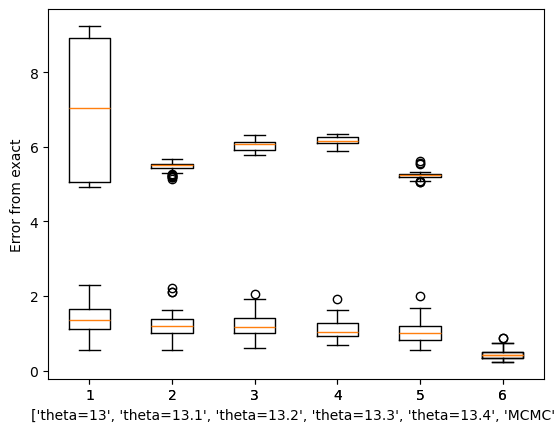

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
AIS_df = pd.DataFrame.from_dict(AIS)
AIS_df["MCMC"] = MCMC
RPS_df = pd.DataFrame.from_dict(RPS)
RPS_df["MCMC"] = MCMC
plt.boxplot(AIS_df)
plt.boxplot(RPS_df)
plt.ylabel("Error from exact")
plt.xlabel(xlabel=["theta=13", "theta=13.1", "theta=13.2", "theta=13.3", "theta=13.4", "MCMC"])

In [37]:
x[0]["AIS_8.6_time"]

84.42495036125183

Quantile plot

In [56]:
import numpy as np
quantile="0.975"
AIS = dict()
RPS = dict()
MCMC = []
for theta in [13, 13.1, 13.2, 13.3, 13.4]:
    AIS[f"{theta}"] = []
    RPS[f"{theta}"] = []
for i in range(len(data)):
    x = data[i]
    MCMC.append(np.sum(np.abs(x["MCMC_quantiles"][quantile]-x["exact_quantiles"][quantile])))
    for theta in [13, 13.1, 13.2, 13.3, 13.4]:        
        RPS_diff = np.sum(np.abs(x[f"RPS_{theta}_quantiles"][quantile]-x["exact_quantiles"][quantile]))
        RPS[f"{theta}"].append(RPS_diff)

        AIS_diff = np.sum(np.abs(x[f"AIS_{theta}_quantiles"][quantile]-x["exact_quantiles"][quantile]))
        AIS[f"{theta}"].append(AIS_diff)

Text(0.5, 0, "['theta=13', 'theta=13.1', 'theta=13.2', 'theta=13.3', 'theta=13.4', 'MCMC']")

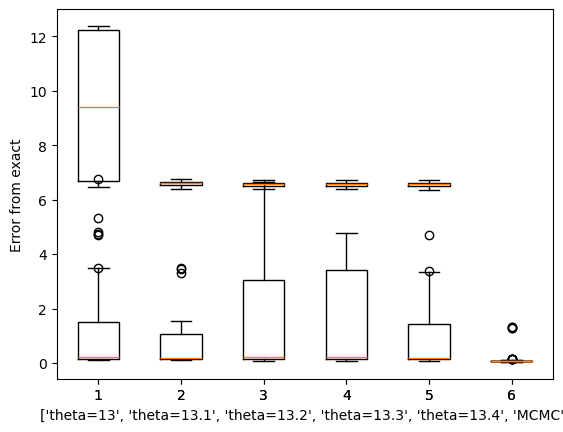

In [57]:
import pandas as pd
AIS_df = pd.DataFrame.from_dict(AIS)
AIS_df["MCMC"] = MCMC
RPS_df = pd.DataFrame.from_dict(RPS)
RPS_df["MCMC"] = MCMC
plt.boxplot(AIS_df)
plt.boxplot(RPS_df)
plt.ylabel("Error from exact")
plt.xlabel(xlabel=["theta=13", "theta=13.1", "theta=13.2", "theta=13.3", "theta=13.4", "MCMC"])

CI overlap plot

In [58]:
import numpy as np

def ci_overlap_frac(a_m, b_m, a_ref, b_ref):
    intersection = np.maximum(0, np.minimum(b_m, b_ref) - np.maximum(a_m, a_ref))
    ref_len = b_ref - a_ref
    return np.where(ref_len > 0, intersection / ref_len, np.nan)

thetas = [13, 13.1, 13.2, 13.3, 13.4]
RPS_overlap = {f"{t}": [] for t in thetas}
AIS_overlap = {f"{t}": [] for t in thetas}
MCMC_overlap = []

for x in data:
    mcmc_lo = x['MCMC_quantiles']['0.025']
    mcmc_hi = x['MCMC_quantiles']['0.975']
    exact_lo = x['exact_quantiles']['0.025']
    exact_hi = x['exact_quantiles']['0.975']
    MCMC_overlap.append(np.nanmean(ci_overlap_frac(mcmc_lo, mcmc_hi, exact_lo, exact_hi)))
    for theta in thetas:
        rps_lo = x[f'RPS_{theta}_quantiles']['0.025']
        rps_hi = x[f'RPS_{theta}_quantiles']['0.975']
        ais_lo = x[f'AIS_{theta}_quantiles']['0.025']
        ais_hi = x[f'AIS_{theta}_quantiles']['0.975']
        RPS_overlap[f"{theta}"].append(np.nanmean(ci_overlap_frac(rps_lo, rps_hi, exact_lo, exact_hi)))
        AIS_overlap[f"{theta}"].append(np.nanmean(ci_overlap_frac(ais_lo, ais_hi, exact_lo, exact_hi)))


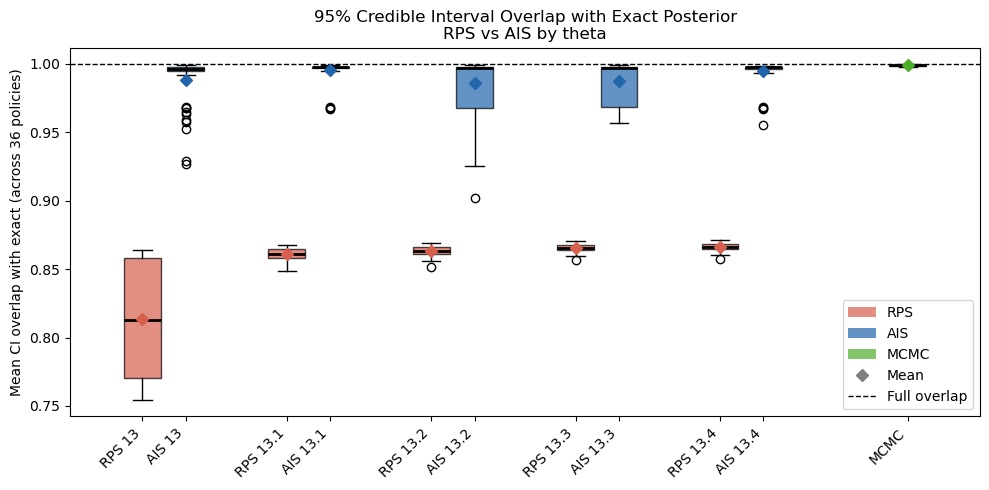

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cols  = list(RPS_overlap.keys())   # theta labels only
x_pos = np.arange(len(cols))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 5))

bp1 = ax.boxplot([RPS_overlap[c] for c in cols], positions=x_pos - width, widths=width*0.85,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp2 = ax.boxplot([AIS_overlap[c] for c in cols], positions=x_pos,          widths=width*0.85,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp3 = ax.boxplot([MCMC_overlap],                 positions=[len(cols)],     widths=width*0.85,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))

for patch in bp1['boxes']:
    patch.set_facecolor('#d6604d'); patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#2166ac'); patch.set_alpha(0.7)
for patch in bp3['boxes']:
    patch.set_facecolor('#4dac26'); patch.set_alpha(0.7)

ax.plot(x_pos - width, [np.mean(RPS_overlap[c]) for c in cols], 'D', color='#d6604d', markersize=6, zorder=5)
ax.plot(x_pos,         [np.mean(AIS_overlap[c]) for c in cols], 'D', color='#2166ac', markersize=6, zorder=5)
ax.plot([len(cols)],   [np.mean(MCMC_overlap)],                 'D', color='#4dac26', markersize=6, zorder=5)

all_ticks  = list(x_pos - width) + list(x_pos) + [len(cols)]
all_labels = [f'RPS {c}' for c in cols] + [f'AIS {c}' for c in cols] + ['MCMC']
ax.set_xticks(sorted(all_ticks))
ax.set_xticklabels([l for _, l in sorted(zip(all_ticks, all_labels))], rotation=45, ha='right')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Mean CI overlap with exact (across 36 policies)')
ax.set_title('95% Credible Interval Overlap with Exact Posterior\nRPS vs AIS by theta')

legend_elements = [
    mpatches.Patch(facecolor='#d6604d', alpha=0.7, label='RPS'),
    mpatches.Patch(facecolor='#2166ac', alpha=0.7, label='AIS'),
    mpatches.Patch(facecolor='#4dac26', alpha=0.7, label='MCMC'),
    plt.Line2D([0],[0], marker='D', color='gray', markersize=6, linestyle='None', label='Mean'),
    plt.Line2D([0],[0], color='black', linestyle='--', linewidth=1, label='Full overlap'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


time plot

Text(0, 0.5, 'Running time in seconds')

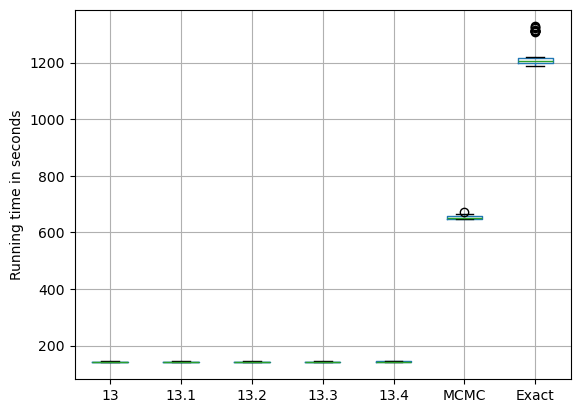

In [18]:
MCMC=[]
exact=[]
AIS=dict()
for theta in [13, 13.1, 13.2, 13.3, 13.4]:
    AIS[f"{theta}"] = []
for i in range(len(data)):
    x = data[i]
    MCMC.append(x[f"MCMC_time"])
    exact.append(x[f"exact_time"])
    for theta in [13, 13.1, 13.2, 13.3, 13.4]:        
        AIS[f"{theta}"].append(x[f"AIS_{theta}_time"])

time_df = pd.DataFrame.from_dict(AIS)
time_df["MCMC"] = MCMC
time_df["Exact"] = exact
time_df.boxplot()
plt.ylabel("Running time in seconds")

In [6]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC
lamb=1
theta=8.6
M = 2
R = np.array([4, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

sigma_00 = None
mu_00 = np.array([0])
# mu_00 = np.array([5])
var_00 = np.array([1])

# Profile (0, 1)
sigma_01 = np.array([[1]])
mu_01 = np.array([-1])
# mu_01 = np.array([10])
var_01 = np.array([1])

# Profile (1, 0)
sigma_10 = np.array([[1, 0]])
mu_10 = np.array([-2, -3])
# mu_10 = np.array([-10, 15])
var_10 = np.array([1, 1])

# Profile (1, 1)
sigma_11 = np.array([[0, 1], [0, np.inf]])
mu_11 = np.array([2, 3, -1, 1])
# mu_11 = np.array([20, 30, 5, 10])
var_11 = np.array([1, 1, 1, 1])

sigma = [sigma_00, sigma_01, sigma_10, sigma_11]
mu = [mu_00, mu_01, mu_10, mu_11]
var = [var_00, var_01, var_10, var_11]

policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

    if np.sum(profile) > 0:
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
        if len(pi_pools_k.keys()) != mu[k].shape[0]:
            print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
        pi_policies[k] = pi_policies_k
        # pi_pools_k has indicies that match with policies_profiles[k]
        # Need to map those indices back to all_policies
        pi_pools[k] = {}
        for x, y in pi_pools_k.items():
            y_full = [policies_profiles[k][i] for i in y]
            y_agg = [all_policies.index(i) for i in y_full]
            pi_pools[k][x] = y_agg
    else:
        pi_policies[k] = {0: 0}
        pi_pools[k] = {0: [0]}

def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
    num_data = num_policies * n_per_pol
    X = np.zeros(shape=(num_data, M))
    D = np.zeros(shape=(num_data, 1), dtype='int_')
    y = np.zeros(shape=(num_data, 1))

    idx_ctr = 0
    for k, profile in enumerate(profiles):
        policies_k = policies_profiles[k]

        for idx, policy in enumerate(policies_k):
            policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

            pool_id = pi_policies[k][idx]
            mu_i = mu[k][pool_id]
            var_i = var[k][pool_id]
            y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

            start_idx = idx_ctr * n_per_pol
            end_idx = (idx_ctr + 1) * n_per_pol

            X[start_idx:end_idx, ] = policy
            D[start_idx:end_idx, ] = policy_idx[0]
            y[start_idx:end_idx, ] = y_i

            idx_ctr += 1

    return X, D, y

num_samples_per_feature = 500
length = []
X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)
# for iter in range(1,51):
#     np.random.seed(iter*42)
#     X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
#     policy_means = loss.compute_policy_means(D, y, num_policies)
#     prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

#     def score_s(state):
#                 Q = AIS.global_loss_raw(
#                     state=state,
#                     D=D, y=y, M=M, R=R,
#                     prof_idx_of_policy = prof_idx_of_policy,
#                     policies=all_policies,
#                     policy_means=policy_means,
#                     reg=lamb, normalize=0,
#                     lattice_edges=None,
#                 )
#                 return float(np.exp(-Q))

#     H = np.inf
#     R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)

#     anchors = AIS.build_anchor_states(R_set, R_profiles, M, R)
#     prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

#     RPS_states = AIS.raggregate_to_states((R_set, R_profiles), profiles)
#     length.append(len(RPS_states))


In [110]:
np.min(length)

np.int64(27)

In [85]:
prob = [score_s(A) for A in RPS_states]

In [63]:
ais_out = AIS.run_ais_streaming_from_data(
                M, 
                R, 
                H, 
                D, 
                y, 
                theta, 
                reg=lamb,
                eps1=0.5,
                eps2=0.75,
                all_policies=all_policies,
                score_s=score_s,
                out_dir="./output_files",
                cfg = cfg,
            )

(0, 0) 7.713983213235162
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 7.787866083122113
Adaptive
Profile (0, 1) took 0.002752065658569336 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.861153034821504
Adaptive
Profile (1, 0) took 0.003144979476928711 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 8.129868070487802
Adaptive
Profile (1, 1) took 0.013110160827636719 s adaptively
Profile (1, 1) has 8 objects in Rashomon set
Finding feasible combinations
Min = 6.104129726871667, Max = 12.96904319944447
Running pilot adaptive ladder
Adaptive ladder has 6 levels; first 10: [0.   0.05 0.15 0.35 0.75 1.  ]
Per-step ESS ratios (len = 5 ): [1.0, 0.9913673317344911, 0.9661198469626824, 0.9435768657754946, 0.9865325923648947]


In [25]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import rashomon
importlib.reload(rashomon.MCMC)

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC
# mcmc_res = MCMC.load_mcmc_res_from_jsonl("./output_files/mcmc_samples1.jsonl")

# log_weight = np.log(np.repeat(1/len(mcmc_res["samples"]), len(mcmc_res["samples"])))

start = time.time()
mcmc_summ2 = MCMC.quantiles_for_all_policies(
    mcmc_res["samples"],
    log_weight,
    D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
    M,
    all_policies,                 # global policies list (len P)
    prof_idx_of_policy,       # length-P array: global policy id -> profile k
    R,                    # per-arm levels (len M)
    lattice_edges=None,
    mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
    p=[0.025,0.5,0.975], 
    seed=None
)
end = time.time()
print(end-start)

# start = time.time()
# mcmc_summ = MCMC.quantiles_for_all_policies_root(
#     mcmc_res["samples"],
#     log_weight,
#     D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
#     M,
#     all_policies,                 # global policies list (len P)
#     prof_idx_of_policy,       # length-P array: global policy id -> profile k
#     R,                    # per-arm levels (len M)
#     lattice_edges=None,
#     mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
#     p=[0.025,0.5,0.975], 
#     seed=None
# )
# end = time.time()
# print(end-start)

57.30595302581787


Check number of rung in temperature ladder

In [40]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC

lamb=1

M = 3
R = np.array([4, 3, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

# Profile (0, 0, 0)
sigma_000 = None
mu_000 = np.array([0])
var_000 = np.array([1])

# Profile (0, 0, 1)
sigma_001 = np.array([[1]])
mu_001 = np.array([-2])
var_001 = np.array([1])

# Profile (0, 1, 0)
sigma_010 = np.array([[1]])
mu_010 = np.array([-1.5])
var_010 = np.array([1])

# Profile (0, 1, 1)
sigma_011 = np.array([[1], [0]])
mu_011 = np.array([-1, 2])
var_011 = np.array([1, 1])

# Profile (1, 0, 0)
sigma_100 = np.array([[0, 1]])
mu_100 = np.array([-1.5, 1])
var_100 = np.array([1, 1])

# Profile (1, 0, 1)
sigma_101 = np.array([[0, 1], [0, np.inf]])
mu_101 = np.array([-0.5, 2.5, 1.5, -2.5])
var_101 = np.array([1, 1, 1, 1])

# Profile (1, 1, 0)
sigma_110 = np.array([[0, 1], [1, np.inf]])
mu_110 = np.array([0, -2.5])
var_110 = np.array([1, 1])

# Profile (1, 1, 1)
sigma_111 = np.array([[0, 1], [1, np.inf], [0, np.inf]])
mu_111 = np.array([3, -0.5, -1.5, -2])
var_111 = np.array([1, 1, 1, 1])

sigma = [sigma_000, sigma_001, sigma_010, sigma_011,
            sigma_100, sigma_101, sigma_110, sigma_111]

mu = [mu_000, mu_001, mu_010, mu_011,
        mu_100, mu_101, mu_110, mu_111]

var = [var_000, var_001, var_010, var_011,
        var_100, var_101, var_110, var_111]

policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
if 1==1:
    for k, profile in enumerate(profiles):

        policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
        unzipped_temp = list(zip(*policies_temp))
        policies_ids_k = list(unzipped_temp[0])
        policies_k = list(unzipped_temp[1])
        policies_profiles[k] = deepcopy(policies_k)
        policies_ids_profiles[k] = policies_ids_k

        profile_mask = list(map(bool, profile))

        # Mask the empty arms
        for idx, pol in enumerate(policies_k):
            policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
        policies_profiles_masked[k] = policies_k

        if np.sum(profile) > 0:
            pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
            if len(pi_pools_k.keys()) != mu[k].shape[0]:
                print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
            pi_policies[k] = pi_policies_k
            # pi_pools_k has indicies that match with policies_profiles[k]
            # Need to map those indices back to all_policies
            pi_pools[k] = {}
            for x, y in pi_pools_k.items():
                y_full = [policies_profiles[k][i] for i in y]
                y_agg = [all_policies.index(i) for i in y_full]
                pi_pools[k][x] = y_agg
        else:
            pi_policies[k] = {0: 0}
            pi_pools[k] = {0: [0]}

    def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
        num_data = num_policies * n_per_pol
        X = np.zeros(shape=(num_data, M))
        D = np.zeros(shape=(num_data, 1), dtype='int_')
        y = np.zeros(shape=(num_data, 1))

        idx_ctr = 0
        for k, profile in enumerate(profiles):
            policies_k = policies_profiles[k]

            for idx, policy in enumerate(policies_k):
                policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

                pool_id = pi_policies[k][idx]
                mu_i = mu[k][pool_id]
                var_i = var[k][pool_id]
                y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

                start_idx = idx_ctr * n_per_pol
                end_idx = (idx_ctr + 1) * n_per_pol

                X[start_idx:end_idx, ] = policy
                D[start_idx:end_idx, ] = policy_idx[0]
                y[start_idx:end_idx, ] = y_i

                idx_ctr += 1

        return X, D, y

X, D, y = generate_data(mu, var, 500, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

In [41]:
for theta in [13, 13.1, 13.2, 13.3, 13.4]:
    H = np.inf
    R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)
    print(len(R_set))

python(78353) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(78354) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(0, 0, 0) 12.025350088462211
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.051797402778933
Adaptive
Profile (0, 0, 1) took 0.0014638900756835938 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.048348699849232
Adaptive
Profile (0, 1, 0) took 0.0014183521270751953 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.107021617581937
Adaptive
Profile (0, 1, 1) took 0.0042688846588134766 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.079574541048009
Adaptive
Profile (1, 0, 0) took 0.0030219554901123047 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.159464257298108
Adaptive
Profile (1, 0, 1) took 0.013206005096435547 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.16559810559546
Adaptive
Profile (1, 1, 0) took 0.012627124786376953 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.327634925200371
Adaptive
Profile (1, 1, 1) took 0

python(78355) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(0, 0, 0) 12.125350088462211
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.151797402778932
Adaptive
Profile (0, 0, 1) took 0.0014529228210449219 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.148348699849231
Adaptive
Profile (0, 1, 0) took 0.0011570453643798828 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.207021617581937
Adaptive
Profile (0, 1, 1) took 0.0047190189361572266 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.179574541048009
Adaptive
Profile (1, 0, 0) took 0.003035306930541992 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.259464257298108
Adaptive
Profile (1, 0, 1) took 0.01299905776977539 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.26559810559546
Adaptive
Profile (1, 1, 0) took 0.012581825256347656 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.42763492520037
Adaptive
Profile (1, 1, 1) took 0.05

python(78356) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(0, 0, 0) 12.22535008846221
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.251797402778932
Adaptive
Profile (0, 0, 1) took 0.0017070770263671875 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.248348699849231
Adaptive
Profile (0, 1, 0) took 0.0013370513916015625 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.307021617581936
Adaptive
Profile (0, 1, 1) took 0.005359649658203125 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.279574541048008
Adaptive
Profile (1, 0, 0) took 0.004223823547363281 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.359464257298107
Adaptive
Profile (1, 0, 1) took 0.014415264129638672 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.36559810559546
Adaptive
Profile (1, 1, 0) took 0.013602733612060547 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.52763492520037
Adaptive
Profile (1, 1, 1) took 0.057

python(78357) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(0, 0, 0) 12.325350088462212
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.351797402778933
Adaptive
Profile (0, 0, 1) took 0.0014579296112060547 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.348348699849232
Adaptive
Profile (0, 1, 0) took 0.0016269683837890625 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.407021617581938
Adaptive
Profile (0, 1, 1) took 0.004544973373413086 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.37957454104801
Adaptive
Profile (1, 0, 0) took 0.0033311843872070312 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.459464257298109
Adaptive
Profile (1, 0, 1) took 0.013617992401123047 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.465598105595461
Adaptive
Profile (1, 1, 0) took 0.013623952865600586 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.627634925200372
Adaptive
Profile (1, 1, 1) took 0.

python(78358) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(0, 0, 0) 12.425350088462212
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.451797402778933
Adaptive
Profile (0, 0, 1) took 0.0015430450439453125 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.448348699849232
Adaptive
Profile (0, 1, 0) took 0.0014181137084960938 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.507021617581938
Adaptive
Profile (0, 1, 1) took 0.004302978515625 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.47957454104801
Adaptive
Profile (1, 0, 0) took 0.0033559799194335938 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.559464257298108
Adaptive
Profile (1, 0, 1) took 0.012829065322875977 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.56559810559546
Adaptive
Profile (1, 1, 0) took 0.012698888778686523 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.727634925200372
Adaptive
Profile (1, 1, 1) took 0.0523